<a href="https://colab.research.google.com/github/routparam12/Python_qns/blob/main/Panelist_behaviour_check.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np


In [6]:
df = pd.read_excel('/content/PanelistAug.xlsx')

In [7]:
df.head()

,panelistId,firstName,lastName,gender,countryId,age,zipCode,email,joinDate,sourceId,ipFraudScore
0,99712,Ronald,Martin,Male,4,47,45133,heskamran4@gmail.com,2025-07-10 21:50:54.353 +0530,[NULL],[NULL]
1,91989,Jakub,Olszewski,Mężczyzna,24,19,17-132,1748613780618_gamekrzywy@gmail.com,2025-05-30 19:30:03.367 +0530,[NULL],[NULL]
2,170603,Sawyer,Mitchell,Male,4,48,28403,sawyermitchell512@gmail.com,2026-07-27 21:56:43.244 +0530,[NULL],0
3,130216,Ahad,Lukas,Male,4,41,42069,zntee1996@gmail.com,2025-11-19 16:42:58.936 +0530,25,[NULL]
4,6827,Alexis,Wynn,Female,4,17,75141,alexiswynn84@gmail.com,2023-10-25 18:02:31.455 +0530,31,[NULL]


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171413 entries, 0 to 171412
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   panelistId    171413 non-null  int64 
 1   firstName     171411 non-null  object
 2   lastName      171398 non-null  object
 3   gender        171413 non-null  object
 4   countryId     171413 non-null  int64 
 5   age           171413 non-null  int64 
 6   zipCode       171411 non-null  object
 7   email         171413 non-null  object
 8   joinDate      171413 non-null  object
 9   sourceId      171413 non-null  object
 10  ipFraudScore  171413 non-null  object
dtypes: int64(3), object(8)
memory usage: 14.4+ MB


In [9]:
df.isnull().sum()

,0
panelistId,0
firstName,2
lastName,15
gender,0
countryId,0
age,0
zipCode,2
email,0
joinDate,0
sourceId,0


In [10]:
df.describe()

,panelistId,countryId,age
count,171413.000000,171413.000000,171413.000000
mean,86984.539947,4.519284,40.139803
std,50224.678768,4.092794,12.327130
min,4.000000,1.000000,0.000000
25%,43285.000000,4.000000,31.000000
50%,87161.000000,4.000000,40.000000
75%,130661.000000,4.000000,47.000000
max,173629.000000,34.000000,582.000000


In [11]:
print(df['sourceId'].value_counts(dropna=False).head(20))


sourceId
[NULL]    88943
22        16264
11        13374
25        11348
24         4986
50         4977
31         4770
21         4459
39         4049
40         3549
29         3372
10         2196
37         1298
28         1015
56          966
67          816
38          803
35          727
49          570
54          379
Name: count, dtype: int64


In [12]:
print(df['ipFraudScore'].unique()[:20])


['[NULL]' 0 70 84 73 38 100 79 15 82 44 12 75 91 94 90 87 77 88 97]


In [13]:
print(df['joinDate'].head())

0    2025-07-10 21:50:54.353 +0530
1    2025-05-30 19:30:03.367 +0530
2    2026-07-27 21:56:43.244 +0530
3    2025-11-19 16:42:58.936 +0530
4    2023-10-25 18:02:31.455 +0530
Name: joinDate, dtype: object


In [17]:
df['joinDate'] = pd.to_datetime(df['joinDate'], errors='coerce')
print("unparsed dates:", df['joinDate'].isna().sum())

# adjust this set after Step 0
NO_SOURCE = {'', '0', 'none', 'null', 'nan', 'direct', '-1'}

src = df['sourceId'].astype(str).str.strip().str.lower()
df['has_source'] = ~src.isin(NO_SOURCE)

df['ipFraudScore'] = pd.to_numeric(df['ipFraudScore'], errors='coerce')
print("non-numeric fraud scores:", df['ipFraudScore'].isna().sum())

df['join_month'] = df['joinDate'].dt.to_period('M').dt.to_timestamp()

unparsed dates: 0
non-numeric fraud scores: 166103


/tmp/ipykernel_3526/3646439767.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['join_month'] = df['joinDate'].dt.to_period('M').dt.to_timestamp()


In [19]:
monthly = (df.groupby('join_month')
             .agg(total_joins=('panelistId','size'),
                  sourced=('has_source','sum'))
             .assign(direct=lambda d: d.total_joins - d.sourced,
                     sourced_pct=lambda d: 100*d.sourced/d.total_joins)
             .reset_index())

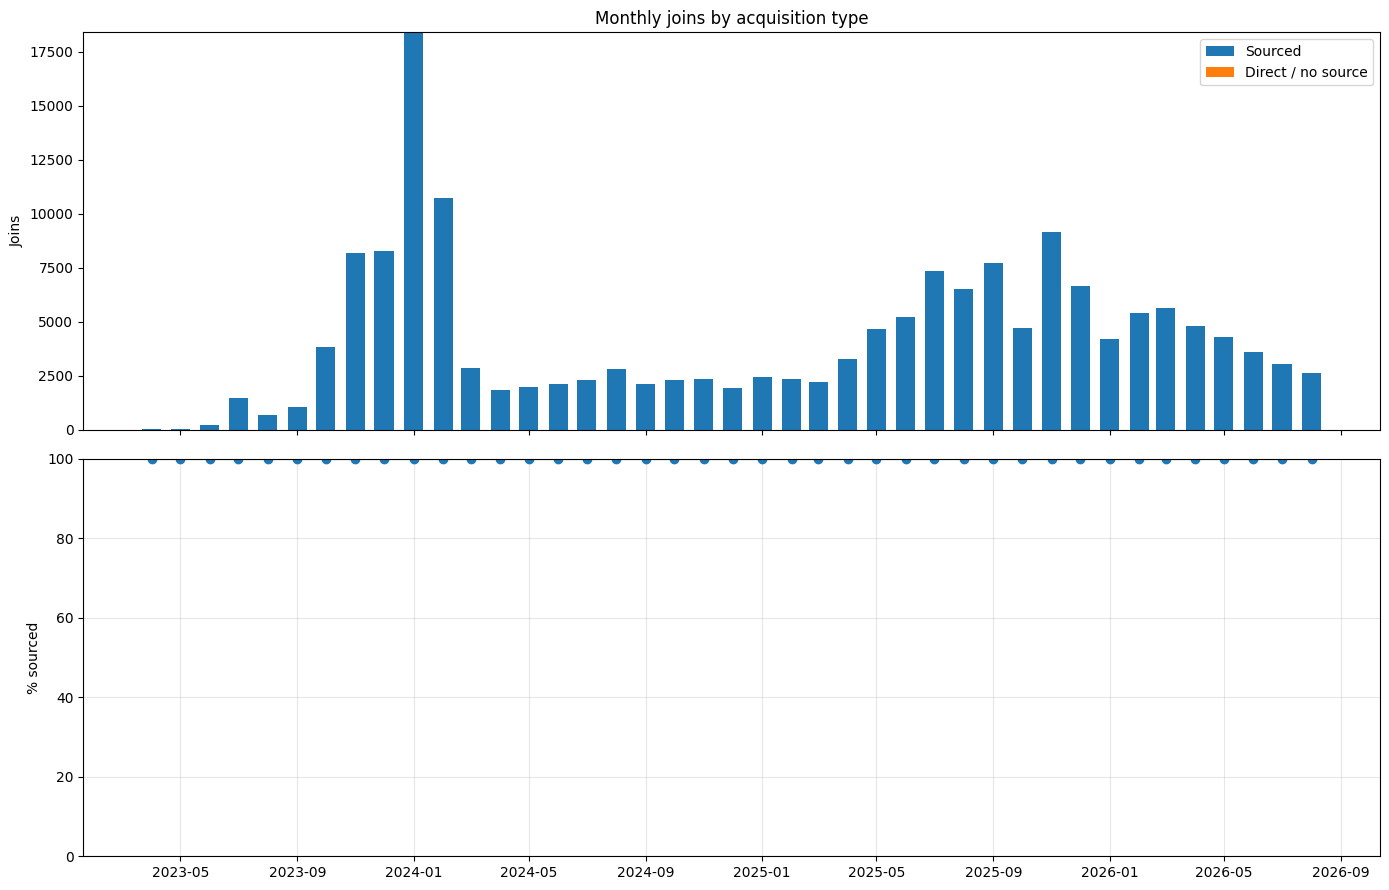

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,1, figsize=(14,9), sharex=True)

ax[0].bar(monthly.join_month, monthly.sourced, width=20, label='Sourced')
ax[0].bar(monthly.join_month, monthly.direct, width=20,
          bottom=monthly.sourced, label='Direct / no source')
ax[0].set_ylabel('Joins'); ax[0].legend(); ax[0].set_title('Monthly joins by acquisition type')

ax[1].plot(monthly.join_month, monthly.sourced_pct, marker='o')
ax[1].set_ylabel('% sourced'); ax[1].set_ylim(0,100); ax[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

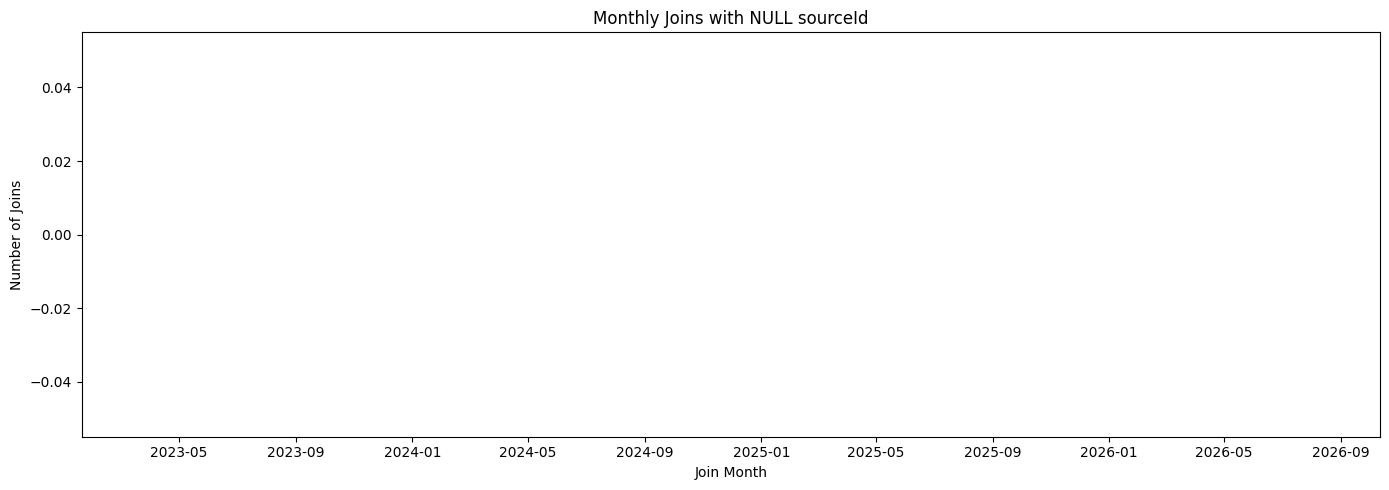

In [23]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly.join_month, monthly.direct, width=20, color='skyblue')
ax.set_title('Monthly Joins with NULL sourceId')
ax.set_xlabel('Join Month')
ax.set_ylabel('Number of Joins')
plt.tight_layout()
plt.show()

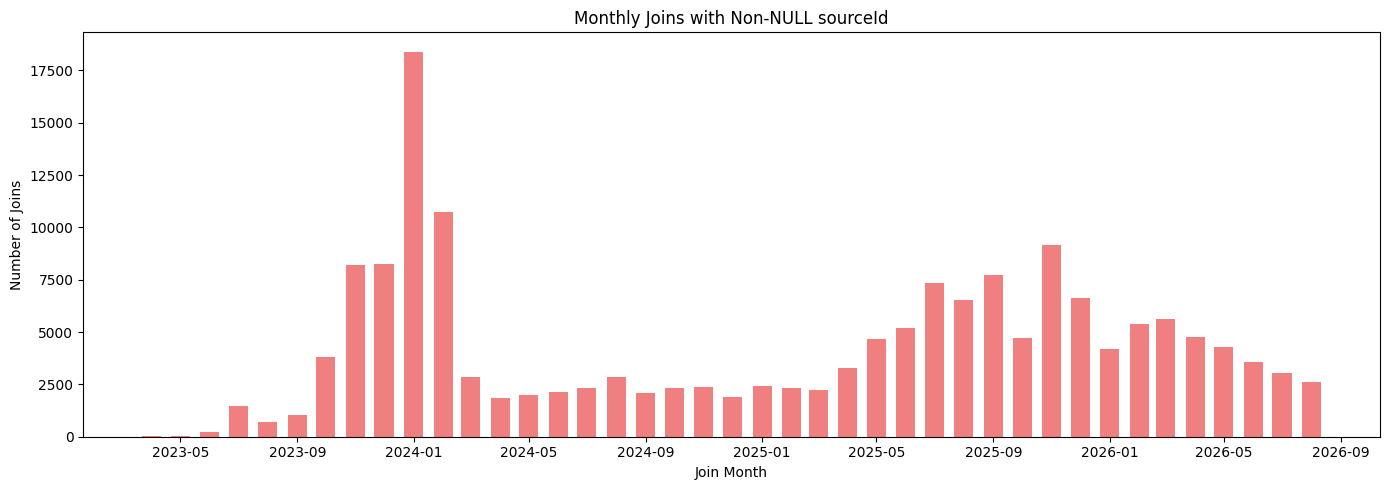

In [24]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly.join_month, monthly.sourced, width=20, color='lightcoral')
ax.set_title('Monthly Joins with Non-NULL sourceId')
ax.set_xlabel('Join Month')
ax.set_ylabel('Number of Joins')
plt.tight_layout()
plt.show()

<Axes: xlabel='join_month'>

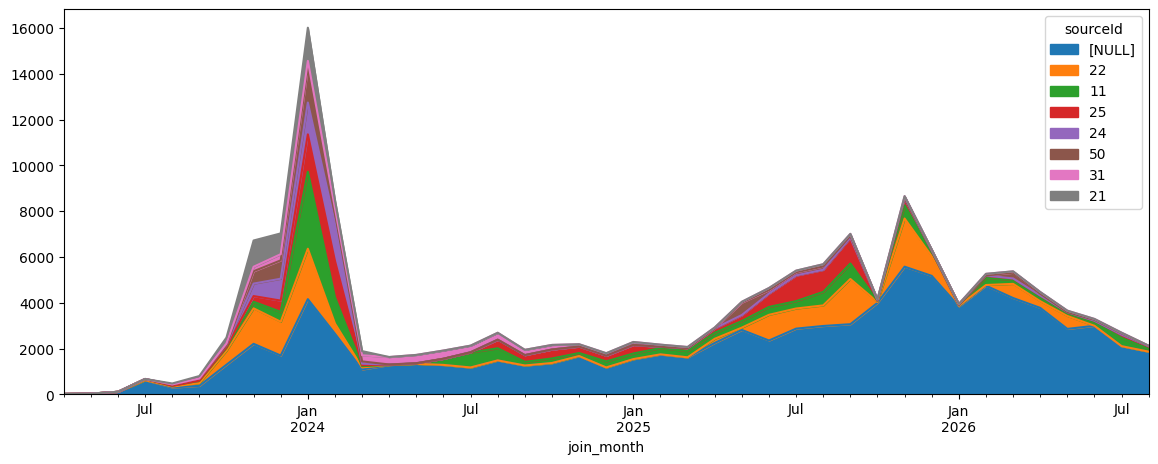

In [21]:
top = df[df.has_source].groupby(['join_month','sourceId']).size().rename('joins').reset_index()
pivot = top.pivot(index='join_month', columns='sourceId', values='joins').fillna(0)
pivot[pivot.sum().nlargest(8).index].plot.area(figsize=(14,5))

In [22]:
(df[df.has_source]
   .groupby('sourceId')
   .agg(joins=('panelistId','size'),
        median_fraud=('ipFraudScore','median'),
        pct_high=('ipFraudScore', lambda s: 100*(s>50).mean()))
   .query('joins > 500')
   .sort_values('pct_high', ascending=False))

,joins,median_fraud,pct_high
sourceId,,,
29,3372,0.0,1.720047
[NULL],88943,0.0,0.427240
40,3549,0.0,0.253593
25,11348,0.0,0.229115
11,13374,0.0,0.216839
31,4770,0.0,0.041929
50,4977,0.0,0.020092
21,4459,NaN,0.000000
10,2196,NaN,0.000000


In [34]:
aug_2026_users = df[df['join_month'] == '2026-08-01']
print(f"Number of users who joined in August 2026: {len(aug_2026_users)}")

Number of users who joined in August 2026: 2621


In [35]:
# Filter out null ipFraudScore and count unique panelistId for each score
fraud_counts = df[df['ipFraudScore'].notna()].groupby('ipFraudScore')['panelistId'].nunique()

# Identify ipFraudScores that have more than 1 unique user
multi_user_fraud_scores = fraud_counts[fraud_counts > 1].index.tolist()

print(f"IP Fraud Scores with more than one user: {multi_user_fraud_scores}")

# Filter the original DataFrame to get all users associated with these fraud scores
users_with_shared_ip = df[df['ipFraudScore'].isin(multi_user_fraud_scores)]

# Display the panelistIds for these users
if not users_with_shared_ip.empty:
    print("\nPanelist IDs for users sharing IP Fraud Scores:")
    display(users_with_shared_ip[['ipFraudScore', 'panelistId']].sort_values(by='ipFraudScore').head(10))
else:
    print("\nNo IP Fraud Scores found with more than one user.")

IP Fraud Scores with more than one user: [0.0, 12.0, 38.0, 44.0, 70.0, 73.0, 75.0, 77.0, 79.0, 82.0, 84.0, 87.0, 88.0, 90.0, 91.0, 94.0, 97.0, 100.0]

Panelist IDs for users sharing IP Fraud Scores:


,ipFraudScore,panelistId
32496,0.0,169375
32511,0.0,169386
32510,0.0,169384
32509,0.0,169383
32508,0.0,169387
32504,0.0,169381
32503,0.0,169372
32499,0.0,169314
32498,0.0,173279
32497,0.0,169380
